### Soal 1 Fuzzy Mamdani

HASIL ANALISIS SISTEM KECEPATAN (FIS MAMDANI)
[1] INPUT SENSOR:
- Visibilitas : 250 m
- Kebasahan   : 6.0
- Kepadatan   : 55 kendaraan/km

[2] DETAIL FUZZIFIKASI (Derajat Keanggotaan):
Visibilitas:
-> buruk: 0.25
-> sedang: 0.25
Kebasahan:
-> basah: 0.67
Kepadatan:
-> sedang: 0.60

[3] ATURAN YANG AKTIF:
Mengingat Visibilitas (Buruk & Sedang), Kebasahan (Basah), dan Kepadatan (Sedang):
-Rule 3 Aktif (Kecepatan Lambat)
-Rule 4 Aktif (Kecepatan Lambat)

[4] HASIL DEFUZZIFIKASI (CENTROID):
    Rekomendasi Kecepatan Aman : 28.77 km/h

[5] PERINGATAN KESELAMATAN:
⚠️ HATI-HATI! Kondisi jalan berisiko tinggi.
-> Jalan licin, kurangi manuver mendadak.
-> Jarak pandang terbatas, nyalakan lampu kabut.
-> Jaga jarak aman dengan kendaraan di depan.


d:\python-3.12.7\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


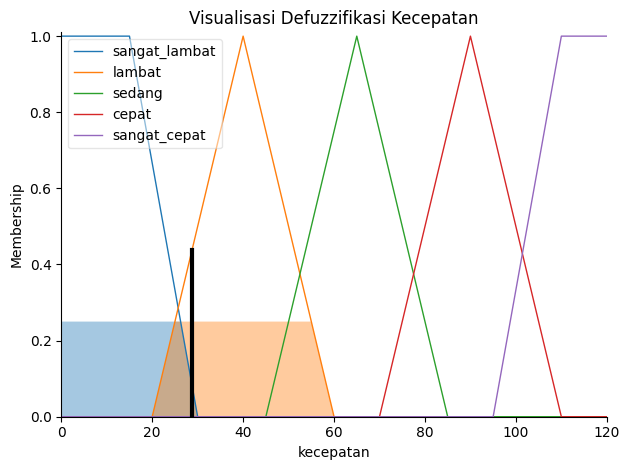

In [1]:

import skfuzzy as fuzz          
import numpy as np              
from skfuzzy import control as ctrl 
import matplotlib.pyplot as plt 

# 1. DEFINISI VARIABEL INPUT & OUTPUT 
visibilitas = ctrl.Antecedent(np.arange(0, 1001, 1), 'visibilitas') 
kebasahan = ctrl.Antecedent(np.arange(0, 11, 0.1), 'kebasahan') 
kepadatan = ctrl.Antecedent(np.arange(0, 101, 1), 'kepadatan') 
kecepatan = ctrl.Consequent(np.linspace(0, 120, 1201), 'kecepatan') 

# 2. FUNGSI KEANGGOTAAN (Mengubah angka pasti menjadi bentuk grafik)

# Himpunan untuk VISIBILITAS (0-1000m)
visibilitas['buruk'] = fuzz.trapmf(visibilitas.universe, [0, 0, 100, 300]) 
visibilitas['sedang'] = fuzz.trimf(visibilitas.universe, [200, 400, 700]) 
visibilitas['baik'] = fuzz.trapmf(visibilitas.universe, [600, 800, 1000, 1000]) 

# Himpunan untuk KEBASAHAN (0-10)
kebasahan['kering'] = fuzz.trapmf(kebasahan.universe, [0, 0, 1, 3]) 
kebasahan['basah'] = fuzz.trimf(kebasahan.universe, [2, 5, 8]) 
kebasahan['sangat_basah'] = fuzz.trapmf(kebasahan.universe, [7, 9, 10, 10]) 

# Himpunan untuk KEPADATAN (0-100 kendaraan/km)
kepadatan['lengang'] = fuzz.trapmf(kepadatan.universe, [0, 0, 10, 30]) 
kepadatan['sedang'] = fuzz.trimf(kepadatan.universe, [20, 45, 70]) 
kepadatan['padat'] = fuzz.trapmf(kepadatan.universe, [60, 80, 100, 100]) 

# Himpunan untuk KECEPATAN (0-120 km/h)
kecepatan['sangat_lambat'] = fuzz.trapmf(kecepatan.universe, [0, 0, 15, 30]) 
kecepatan['lambat'] = fuzz.trimf(kecepatan.universe, [20, 40, 60]) 
kecepatan['sedang'] = fuzz.trimf(kecepatan.universe, [45, 65, 85]) 
kecepatan['cepat'] = fuzz.trimf(kecepatan.universe, [70, 90, 110]) 
kecepatan['sangat_cepat'] = fuzz.trapmf(kecepatan.universe, [95, 110, 120, 120]) 

# 3. BASIS ATURAN (Membangun logika berpikir sistem)
rule1 = ctrl.Rule(visibilitas['buruk'] | kebasahan['sangat_basah'], kecepatan['sangat_lambat'])
rule2 = ctrl.Rule(visibilitas['buruk'] & kebasahan['basah'] & kepadatan['padat'], kecepatan['sangat_lambat'])
rule3 = ctrl.Rule(visibilitas['buruk'] & kebasahan['basah'] & kepadatan['sedang'], kecepatan['lambat'])
rule4 = ctrl.Rule(visibilitas['sedang'] & kebasahan['basah'] & kepadatan['sedang'], kecepatan['lambat'])
rule5 = ctrl.Rule(visibilitas['sedang'] & kebasahan['basah'] & kepadatan['padat'], kecepatan['sangat_lambat'])
rule6 = ctrl.Rule(visibilitas['baik'] & kebasahan['kering'] & kepadatan['lengang'], kecepatan['sangat_cepat'])
rule7 = ctrl.Rule(visibilitas['baik'] & kebasahan['kering'] & kepadatan['sedang'], kecepatan['sedang'])
rule8 = ctrl.Rule(visibilitas['baik'] & kebasahan['kering'] & kepadatan['padat'], kecepatan['lambat'])
rule9 = ctrl.Rule(visibilitas['baik'] & kebasahan['basah'] & kepadatan['lengang'], kecepatan['cepat'])
rule10 = ctrl.Rule(visibilitas['sedang'] & kebasahan['kering'] & kepadatan['lengang'], kecepatan['cepat'])
rule11 = ctrl.Rule(visibilitas['sedang'] & kebasahan['kering'] & kepadatan['sedang'], kecepatan['sedang'])
rule12 = ctrl.Rule(visibilitas['baik'] & kebasahan['sangat_basah'] & kepadatan['lengang'], kecepatan['sedang'])

# 4. SISTEM KONTROL & SIMULASI (Mempersiapkan mesin pemroses)
# Menggabungkan 12 aturan terpisah menjadi satu kesatuan otak (ControlSystem)
kecepatan_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12])

# Membuat wadah eksekusi (Simulation) agar kita bisa memasukkan nilai tes ke dalamnya
simulasi = ctrl.ControlSystemSimulation(kecepatan_ctrl)

# 5. MEMBERIKAN NILAI INPUT TESTING
input_visibilitas = 250
input_kebasahan = 6.0
input_kepadatan = 55

# Memasukkan angka ke simulasi
simulasi.input['visibilitas'] = input_visibilitas
simulasi.input['kebasahan'] = input_kebasahan
simulasi.input['kepadatan'] = input_kepadatan

# 6. MENGHITUNG OUTPUT (Proses utama: Fuzzifikasi -> Inferensi -> Defuzzifikasi)
simulasi.compute()

# Menyimpan hasil akhir perhitungan (satu angka pasti) ke dalam variabel
hasil_kecepatan = simulasi.output['kecepatan']

# 7. MENAMPILKAN OUTPUT
print("="*50)
print("HASIL ANALISIS SISTEM KECEPATAN (FIS MAMDANI)")
print("="*50)

# A. Cetak nilai asli yang dimasukkan
print(f"[1] INPUT SENSOR:")
print(f"- Visibilitas : {input_visibilitas} m")
print(f"- Kebasahan   : {input_kebasahan}")
print(f"- Kepadatan   : {input_kepadatan} kendaraan/km\n")

print("[2] DETAIL FUZZIFIKASI (Derajat Keanggotaan):")

# Fungsi kustom ini mencari titik temu antara angka input dengan garis kurva grafiknya
def print_fuzz(nama, universe, nilai, himpunan_dict):
    print(f"{nama}:")
    for label, fungsi in himpunan_dict.items():
        # fuzz.interp_membership bertugas membaca ketinggian kurva (dari 0.0 sampai 1.0)
        derajat = fuzz.interp_membership(universe, fungsi.mf, nilai)
        # Hanya mencetak yang nilainya lebih besar dari 0 (berarti masuk kategori tersebut)
        if derajat > 0:
            print(f"-> {label}: {derajat:.2f}")

# Memanggil fungsi di atas untuk masing-masing variabel input
print_fuzz("Visibilitas", visibilitas.universe, input_visibilitas, visibilitas.terms)
print_fuzz("Kebasahan", kebasahan.universe, input_kebasahan, kebasahan.terms)
print_fuzz("Kepadatan", kepadatan.universe, input_kepadatan, kepadatan.terms)

# B. Mencetak informasi aturan mana yang terpicu 
print("\n[3] ATURAN YANG AKTIF:")
print("Mengingat Visibilitas (Buruk & Sedang), Kebasahan (Basah), dan Kepadatan (Sedang):")
print("-Rule 3 Aktif (Kecepatan Lambat)")
print("-Rule 4 Aktif (Kecepatan Lambat)")

# C. Mencetak hasil akhir setelah area grafik dilebur mencari titik berat (Centroid)
print(f"\n[4] HASIL DEFUZZIFIKASI (CENTROID):")
print(f"    Rekomendasi Kecepatan Aman : {hasil_kecepatan:.2f} km/h")

# D. Sistem If-Else biasa (Non-Fuzzy) untuk memberikan saran berupa teks
print("\n[5] PERINGATAN KESELAMATAN:")
if hasil_kecepatan < 45: # Jika rekomendasi kecepatannya sangat pelan
    print("⚠️ HATI-HATI! Kondisi jalan berisiko tinggi.")
    if input_kebasahan >= 5.0: print("-> Jalan licin, kurangi manuver mendadak.")
    if input_visibilitas <= 300: print("-> Jarak pandang terbatas, nyalakan lampu kabut.")
    if input_kepadatan >= 45:  print("-> Jaga jarak aman dengan kendaraan di depan.")
elif hasil_kecepatan >= 85: # Jika rekomendasi kecepatannya tinggi
    print("✅ Kondisi jalan optimal, kecepatan maksimal diizinkan.")
else: # Kondisi kecepatan di tengah-tengah
    print("ℹ️ Kondisi jalan standar, berkendaralah dengan normal.")

# 8. MENAMPILKAN VISUALISASI GRAFIK
kecepatan.view(sim=simulasi)
plt.title("Visualisasi Defuzzifikasi Kecepatan")
plt.tight_layout()
plt.show()

### Soal 2 Fuzzy Sugeno Orde 1

SISTEM PREDIKSI HARGA RUMAH

[1] INPUT
 Luas Tanah = 180 m² 
 Jarak Kota = 12 km

[2] HASIL FUZZIFIKASI (Derajat Keanggotaan)
LUAS:
    - kecil : 0.00
    - sedang : 0.80
    - besar : 0.00
JARAK:
    - dekat : 0.30
    - sedang : 0.17
    - jauh : 0.00

[3] z_i PER ATURAN
    Aturan   | w_i (Kekuatan)  | z_i (Harga Linear)
    ---------------------------------------------
    R1       | 0.00            | Rp 600.00     jt  -
    R2       | 0.00            | Rp 424.00     jt  -
    R3       | 0.00            | Rp 258.00     jt  -
    R4       | 0.30            | Rp 692.00     jt  AKTIF
    R5       | 0.17            | Rp 546.00     jt  AKTIF
    R6       | 0.00            | Rp 400.00     jt  -
    R7       | 0.00            | Rp 834.00     jt  -
    R8       | 0.00            | Rp 678.00     jt  -
    R9       | 0.00            | Rp 572.00     jt  -

[4] DEFUZZIFIKASI (Weighted Average):
    Sigma (w_i * z_i) = 298.60
    Sigma (w_i)       = 0.47
 PREDIKSI HARGA RUMAH FINAL : Rp 639.86 

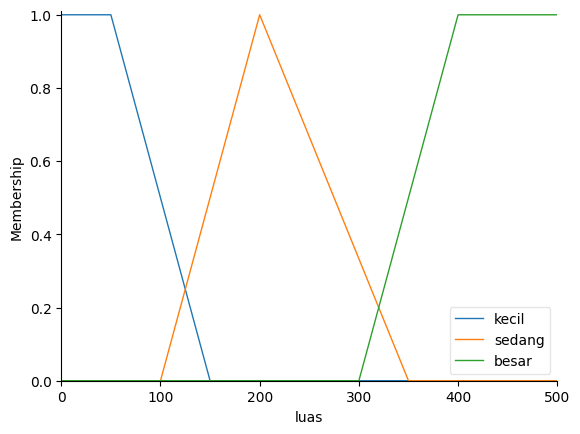

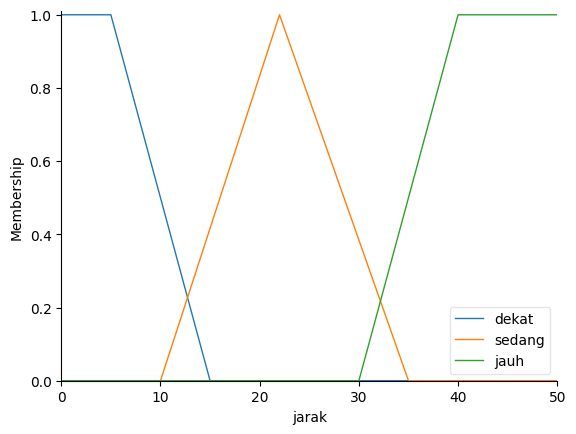

In [ ]:
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


# 1. DEFINISI VARIABEL
luas = ctrl.Antecedent(np.arange(0, 501, 1), 'luas')
jarak = ctrl.Antecedent(np.arange(0, 51, 1), 'jarak')

# 2. FUNGSI KEANGGOTAAN
luas['kecil'] = fuzz.trapmf(luas.universe, [0,0,50,150])
luas['sedang'] = fuzz.trimf(luas.universe, [100,200,350])
luas['besar'] = fuzz.trapmf(luas.universe, [300,400,500,500])
luas.view()

jarak['dekat'] = fuzz.trapmf(jarak.universe, [0,0,5,15])
jarak['sedang'] = fuzz.trimf(jarak.universe, [10,22,35])
jarak['jauh'] = fuzz.trapmf(jarak.universe, [30,40,50,50])
jarak.view()

# 3. INPUT TESTING
input_luas = 180
input_jarak = 12

# 4. FUZZIFIKASI (Ekstrak Nilai dari variabel)
derajat_luas ={
    'kecil' : fuzz.interp_membership(luas.universe, luas['kecil'].mf, input_luas),
    'sedang' : fuzz.interp_membership(luas.universe, luas['sedang'].mf, input_luas),
    'besar' : fuzz.interp_membership(luas.universe, luas['besar'].mf, input_luas)
}

derajat_jarak ={
    'dekat' : fuzz.interp_membership(jarak.universe, jarak['dekat'].mf, input_jarak),
    'sedang' : fuzz.interp_membership(jarak.universe, jarak['sedang'].mf, input_jarak),
    'jauh' : fuzz.interp_membership(jarak.universe, jarak['jauh'].mf, input_jarak)
}

# 5. BASIS ATURAN
# w = firing strength, z = fungsi linear
rules = [
    {"nama": "R1", "w": min(derajat_luas['kecil'], derajat_jarak['dekat']), 
     "z": 2.0*input_luas + (-5.0)*input_jarak + 300},
     
    {"nama": "R2", "w": min(derajat_luas['kecil'], derajat_jarak['sedang']), 
     "z": 1.5*input_luas + (-8.0)*input_jarak + 250},
     
    {"nama": "R3", "w": min(derajat_luas['kecil'], derajat_jarak['jauh']), 
     "z": 1.0*input_luas + (-6.0)*input_jarak + 150},
     
    {"nama": "R4", "w": min(derajat_luas['sedang'], derajat_jarak['dekat']), 
     "z": 3.0*input_luas + (-4.0)*input_jarak + 200},
     
    {"nama": "R5", "w": min(derajat_luas['sedang'], derajat_jarak['sedang']), 
     "z": 2.5*input_luas + (-7.0)*input_jarak + 180},
     
    {"nama": "R6", "w": min(derajat_luas['sedang'], derajat_jarak['jauh']), 
     "z": 2.0*input_luas + (-5.0)*input_jarak + 100},
     
    {"nama": "R7", "w": min(derajat_luas['besar'], derajat_jarak['dekat']), 
     "z": 4.0*input_luas + (-3.0)*input_jarak + 150},
     
    {"nama": "R8", "w": min(derajat_luas['besar'], derajat_jarak['sedang']), 
     "z": 3.5*input_luas + (-6.0)*input_jarak + 120},
     
    {"nama": "R9", "w": min(derajat_luas['besar'], derajat_jarak['jauh']), 
     "z": 3.0*input_luas + (-4.0)*input_jarak + 80}
]

# 6. DEFUZZIFIKASI
# Menjumlahkan w dan z bedasarkan aturan yg didapatkan
total_wz = sum(i['w'] * i['z'] for i in rules)
# Menjumlah w
total_w = sum(r['w'] for r in rules)
# Menerapkan rumus weighted average
harga_akhir = total_wz / total_w


# 7. OUTPUT AKHIR
print("="*50)
print("SISTEM PREDIKSI HARGA RUMAH")
print("="*50)

print(f"\n[1] INPUT\n Luas Tanah = {input_luas} m² \n Jarak Kota = {input_jarak} km")

print(f"\n[2] HASIL FUZZIFIKASI (Derajat Keanggotaan)")
print("LUAS:")
for i, j in derajat_luas.items():
    print(f"    - {i} : {j:.2f}")
print("JARAK:")
for i, j in derajat_jarak.items():
    print(f"    - {i} : {j:.2f}")

print(f"\n[3] z_i PER ATURAN")
print(f"    {'Aturan':<8} | {'w_i (Kekuatan)':<15} | {'z_i (Harga Linear)':<15}")
print("    " + "-"*45)
for r in rules:
    status = "AKTIF" if r['w'] > 0 else "-"
    print(f"    {r['nama']:<8} | {r['w']:<15.2f} | Rp {r['z']:<10.2f} jt  {status}")


print(f"\n[4] DEFUZZIFIKASI (Weighted Average):")
print(f"    Sigma (w_i * z_i) = {total_wz:.2f}")
print(f"    Sigma (w_i)       = {total_w:.2f}")


print(f" PREDIKSI HARGA RUMAH FINAL : Rp {harga_akhir:.2f} Juta")


### Soal 3 Fuzzy Mamdani dengan Operasi Himpunan Lengkap

 SISTEM DIAGNOSIS KESEHATAN TANAMAN (FIS MAMDANI) 

[1] INPUT SENSOR:
    - Kelembaban : 45 %
    - Cahaya     : 5000 lux
    - Suhu       : 27 °C

[2] PEMBUKTIAN OPERASI HIMPUNAN FUZZY:
    Derajat Kelembaban (Lembab) : 0.80
    Derajat Cahaya (Teduh)      : 0.80
    Derajat Suhu (Optimal)      : 0.80

    A. Operasi AND (Min) -> pada Rule 3:
       min(0.80, 0.80, 0.80) = 0.80

    B. Operasi OR (Max) -> pada Rule 1:
       max(Kering:0.00, Panas:0.00) = 0.00

    C. Operasi NOT (1 - μ) -> pada Rule 5 (~Lembab):
       1 - 0.80 = 0.20

[3] OPERASI α-CUT (Alpha = 0.5) PADA HIMPUNAN DOMINAN:
    - Kelembaban 'Lembab' terpotong di rentang X : 38.0% s.d 62.0%
    - Cahaya 'Teduh' terpotong di rentang X     : 3250.0 s.d 5750.0 lux
    - Suhu 'Optimal' terpotong di rentang X     : 20.0°C s.d 30.0°C

[4] HASIL AKHIR (DEFUZZIFIKASI CENTROID):
    Skor Kesehatan Tanaman : 75.00 / 100
    Kesimpulan: Sehat (Memenuhi target 70-90 sesuai skenario tolak ukur!)


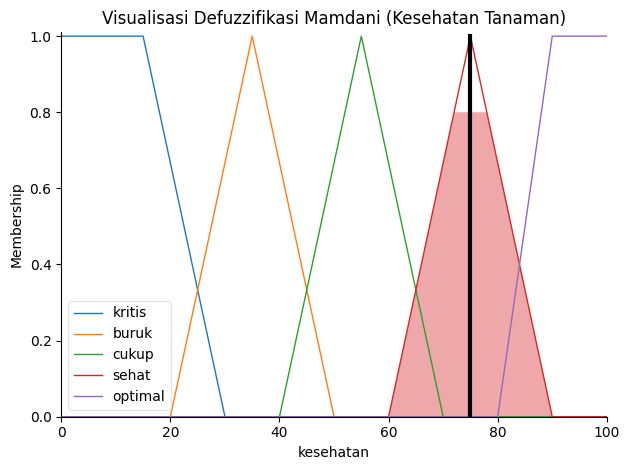

In [12]:
import skfuzzy as fuzz 
import numpy as np 
from skfuzzy import control as ctrl 
import matplotlib.pyplot as plt 

# 1. DEFINISI VARIABEL INPUT & OUTPUT
kelembaban = ctrl.Antecedent(np.arange(0, 101, 1), 'kelembaban') 
cahaya = ctrl.Antecedent(np.arange(0, 10001, 1), 'cahaya') 
suhu = ctrl.Antecedent(np.arange(0, 51, 1), 'suhu') 

# Defuzzifikasi Centroid 
kesehatan = ctrl.Consequent(np.arange(0, 101, 1), 'kesehatan') 

# 2. FUNGSI KEANGGOTAAN
# KELEMBABAN (0-100%)
kelembaban['kering'] = fuzz.trapmf(kelembaban.universe, [0, 0, 15, 35]) 
kelembaban['lembab'] = fuzz.trimf(kelembaban.universe, [25, 50, 75]) 
kelembaban['basah'] = fuzz.trapmf(kelembaban.universe, [65, 85, 100, 100]) 

# CAHAYA (0-10000 lux)
cahaya['gelap'] = fuzz.trapmf(cahaya.universe, [0, 0, 1000, 3000]) 
cahaya['teduh'] = fuzz.trimf(cahaya.universe, [2000, 4500, 7000]) 
cahaya['terang'] = fuzz.trapmf(cahaya.universe, [6000, 8000, 10000, 10000]) 

# SUHU (0-50 C)
suhu['dingin'] = fuzz.trapmf(suhu.universe, [0, 0, 10, 20]) 
suhu['optimal'] = fuzz.trimf(suhu.universe, [15, 25, 35]) 
suhu['panas'] = fuzz.trapmf(suhu.universe, [30, 40, 50, 50]) 

# KESEHATAN (0-100)
kesehatan['kritis'] = fuzz.trapmf(kesehatan.universe, [0, 0, 15, 30]) 
kesehatan['buruk'] = fuzz.trimf(kesehatan.universe, [20, 35, 50]) 
kesehatan['cukup'] = fuzz.trimf(kesehatan.universe, [40, 55, 70]) 
kesehatan['sehat'] = fuzz.trimf(kesehatan.universe, [60, 75, 90]) 
kesehatan['optimal'] = fuzz.trapmf(kesehatan.universe, [80, 90, 100, 100]) 

# 3. BASIS ATURAN (10 Aturan dengan AND, OR, dan NOT)
rule1 = ctrl.Rule(kelembaban['kering'] | suhu['panas'], kesehatan['buruk']) 
rule2 = ctrl.Rule(kelembaban['basah'] & cahaya['gelap'], kesehatan['kritis']) 
rule3 = ctrl.Rule(kelembaban['lembab'] & cahaya['teduh'] & suhu['optimal'], kesehatan['sehat']) 
rule4 = ctrl.Rule(kelembaban['lembab'] & cahaya['terang'] & suhu['optimal'], kesehatan['optimal']) 
rule5 = ctrl.Rule(~kelembaban['lembab'] & suhu['panas'], kesehatan['kritis'])
rule6 = ctrl.Rule(kelembaban['kering'] & cahaya['terang'], kesehatan['buruk']) 
rule7 = ctrl.Rule(kelembaban['basah'] | suhu['dingin'], kesehatan['cukup']) 
rule8 = ctrl.Rule(kelembaban['lembab'] & cahaya['gelap'] & suhu['optimal'], kesehatan['cukup']) 
rule9 = ctrl.Rule(kelembaban['lembab'] & cahaya['terang'] & suhu['dingin'], kesehatan['cukup']) 
rule10 = ctrl.Rule(kelembaban['lembab'] & cahaya['teduh'] & suhu['panas'], kesehatan['buruk']) 

# 4. SIMULASI & INPUT TESTING
kesehatan_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10])
simulasi = ctrl.ControlSystemSimulation(kesehatan_ctrl)

input_kelembapan = 45
input_cahaya = 5000
input_suhu = 27

simulasi.input['kelembaban'] = input_kelembapan
simulasi.input['cahaya'] = input_cahaya
simulasi.input['suhu'] = input_suhu
simulasi.compute()

hasil_kesehatan = simulasi.output['kesehatan']

# 5. MENAMPILKAN OUTPUT AKHIR
print("="*55)
print(" SISTEM DIAGNOSIS KESEHATAN TANAMAN (FIS MAMDANI) ")
print("="*55)

print(f"\n[1] INPUT SENSOR:")
print(f"    - Kelembaban : {input_kelembapan} %")
print(f"    - Cahaya     : {input_cahaya} lux")
print(f"    - Suhu       : {input_suhu} °C")

#  MENGAMBIL NILAI DERAJAT (miu)
miu_kel_lembab = fuzz.interp_membership(kelembaban.universe, kelembaban['lembab'].mf, input_kelembapan)
miu_cah_teduh  = fuzz.interp_membership(cahaya.universe, cahaya['teduh'].mf, input_cahaya)
miu_suhu_opt   = fuzz.interp_membership(suhu.universe, suhu['optimal'].mf, input_suhu)
miu_suhu_panas = fuzz.interp_membership(suhu.universe, suhu['panas'].mf, input_suhu)

print(f"\n[2] PEMBUKTIAN OPERASI HIMPUNAN FUZZY:")
print(f"    Derajat Kelembaban (Lembab) : {miu_kel_lembab:.2f}")
print(f"    Derajat Cahaya (Teduh)      : {miu_cah_teduh:.2f}")
print(f"    Derajat Suhu (Optimal)      : {miu_suhu_opt:.2f}")

# A. Bukti Operasi AND (Min)
val_and = min(miu_kel_lembab, miu_cah_teduh, miu_suhu_opt)
print(f"\n    A. Operasi AND (Min) -> pada Rule 3:")
print(f"       min({miu_kel_lembab:.2f}, {miu_cah_teduh:.2f}, {miu_suhu_opt:.2f}) = {val_and:.2f}")

# B. Bukti Operasi OR (Max)
miu_kel_kering = fuzz.interp_membership(kelembaban.universe, kelembaban['kering'].mf, input_kelembapan)
val_or = max(miu_kel_kering, miu_suhu_panas)
print(f"\n    B. Operasi OR (Max) -> pada Rule 1:")
print(f"       max(Kering:{miu_kel_kering:.2f}, Panas:{miu_suhu_panas:.2f}) = {val_or:.2f}")

# C. Bukti Operasi NOT (1 - miu)
val_not = 1 - miu_kel_lembab
print(f"\n    C. Operasi NOT (1 - μ) -> pada Rule 5 (~Lembab):")
print(f"       1 - {miu_kel_lembab:.2f} = {val_not:.2f}")

# PEMBUKTIAN ALPHA-CUT
def hitung_alpha_cut(universe, mf, alpha=0.5):
    # Mencari titik X di mana nilai Y (membership) >= alpha
    indices = np.where(mf >= alpha)[0]
    if len(indices) == 0: return None
    return (universe[indices[0]], universe[indices[-1]])

print(f"\n[3] OPERASI α-CUT (Alpha = 0.5) PADA HIMPUNAN DOMINAN:")
ac_kel = hitung_alpha_cut(kelembaban.universe, kelembaban['lembab'].mf, 0.5)
ac_cah = hitung_alpha_cut(cahaya.universe, cahaya['teduh'].mf, 0.5)
ac_suhu = hitung_alpha_cut(suhu.universe, suhu['optimal'].mf, 0.5)

print(f"    - Kelembaban 'Lembab' terpotong di rentang X : {ac_kel[0]:.1f}% s.d {ac_kel[1]:.1f}%")
print(f"    - Cahaya 'Teduh' terpotong di rentang X     : {ac_cah[0]:.1f} s.d {ac_cah[1]:.1f} lux")
print(f"    - Suhu 'Optimal' terpotong di rentang X     : {ac_suhu[0]:.1f}°C s.d {ac_suhu[1]:.1f}°C")

# OUTPUT DEFUZZIFIKASI 
print(f"\n[4] HASIL AKHIR (DEFUZZIFIKASI CENTROID):")
print(f"    Skor Kesehatan Tanaman : {hasil_kesehatan:.2f} / 100")

if 70 <= hasil_kesehatan <= 90:
    print("    Kesimpulan: Sehat (Memenuhi target 70-90 sesuai skenario tolak ukur!)")

# Visualisasi
kesehatan.view(sim=simulasi)
plt.title("Visualisasi Defuzzifikasi Mamdani (Kesehatan Tanaman)")
plt.tight_layout()
plt.show()